In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB

In [10]:
df = pd.read_csv("iris.csv")

In [11]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
48,5.3,3.7,1.5,0.2,Iris-setosa
88,5.6,3.0,4.1,1.3,Iris-versicolor
125,7.2,3.2,6.0,1.8,Iris-virginica
33,5.5,4.2,1.4,0.2,Iris-setosa
82,5.8,2.7,3.9,1.2,Iris-versicolor


In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
encoder = LabelEncoder()

In [14]:
df['species'] = encoder.fit_transform(df['species'])

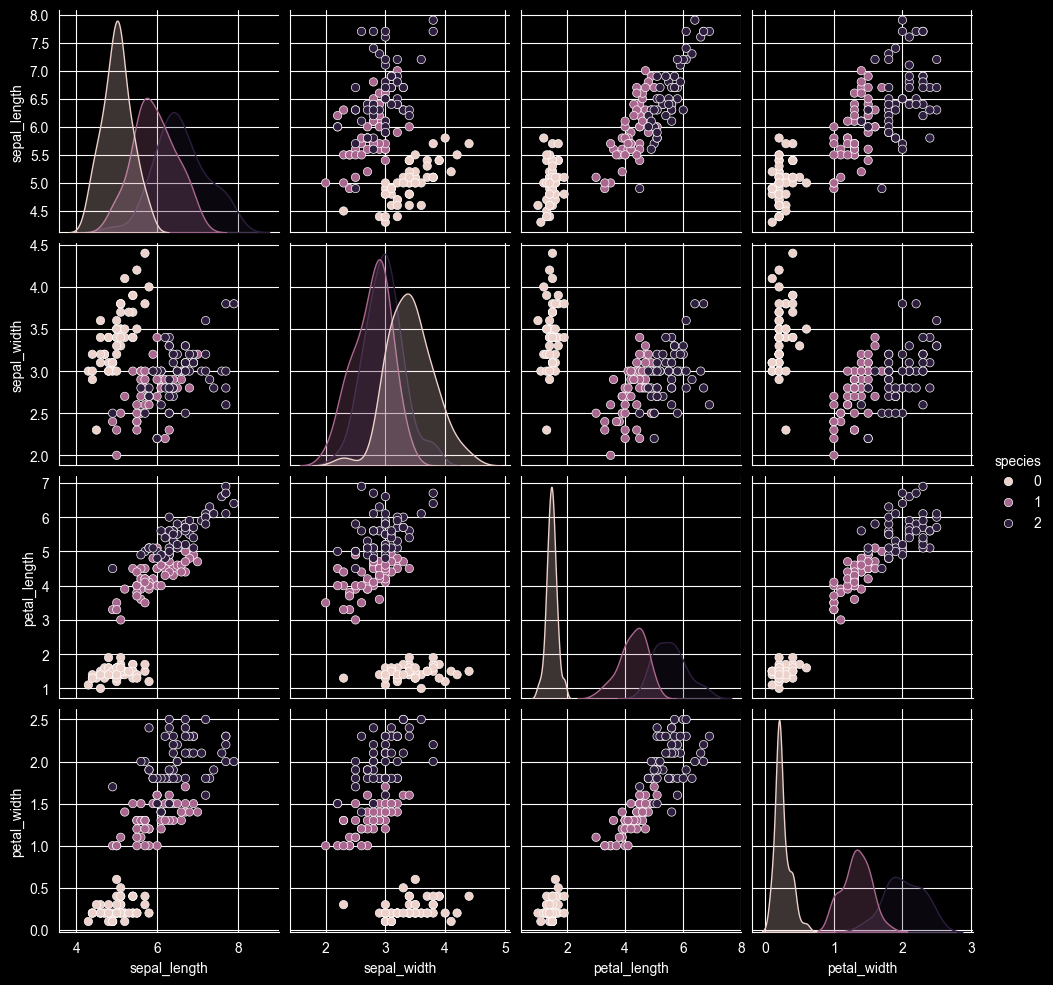

In [15]:
sns.pairplot(df, hue='species')

In [17]:
new_df = df[df['species'] != 0][['sepal_length', 'sepal_width', 'species']]

In [18]:
new_df.head()

,sepal_length,sepal_width,species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


In [19]:
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [21]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()

In [22]:
estimators = [('lr', clf1),('rf', clf2),('knn', clf3)]

In [23]:
for estimator in estimators:
    x = cross_val_score(estimator[1], X, y, cv=10, scoring='accuracy')
    print(estimator[0], np.round(np.mean(x), 2))

lr 0.81
rf 0.71
knn 0.76


In [24]:
from sklearn.ensemble import VotingClassifier

Hard Voting

In [25]:
vc = VotingClassifier(estimators=estimators, voting='hard')
x = cross_val_score(vc, X, y, cv=10, scoring='accuracy')
print(np.round(np.mean(x), 2))

0.78


Soft Voting


In [26]:
vc1 = VotingClassifier(estimators=estimators, voting='soft')
x = cross_val_score(vc1, X, y, cv=10, scoring='accuracy')
print(np.round(np.mean(x), 2))

0.75


Weighted Voting

In [27]:
for i in range(1, 4):
    for j in range(1, 4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators, voting='soft', weights=[i, j, k])
            x = cross_val_score(vc, X, y, cv=10, scoring='accuracy')
            print("for i = {}, j = {}, k = {}".format(i, j, k), np.round(np.mean(x), 2))

for i = 1, j = 1, k = 1 0.76
for i = 1, j = 1, k = 2 0.76
for i = 1, j = 1, k = 3 0.76
for i = 1, j = 2, k = 1 0.75
for i = 1, j = 2, k = 2 0.77
for i = 1, j = 2, k = 3 0.75
for i = 1, j = 3, k = 1 0.74
for i = 1, j = 3, k = 2 0.75
for i = 1, j = 3, k = 3 0.76
for i = 2, j = 1, k = 1 0.79
for i = 2, j = 1, k = 2 0.77
for i = 2, j = 1, k = 3 0.77
for i = 2, j = 2, k = 1 0.76
for i = 2, j = 2, k = 2 0.77
for i = 2, j = 2, k = 3 0.76
for i = 2, j = 3, k = 1 0.75
for i = 2, j = 3, k = 2 0.77
for i = 2, j = 3, k = 3 0.77
for i = 3, j = 1, k = 1 0.8
for i = 3, j = 1, k = 2 0.78
for i = 3, j = 1, k = 3 0.79
for i = 3, j = 2, k = 1 0.77
for i = 3, j = 2, k = 2 0.77
for i = 3, j = 2, k = 3 0.77
for i = 3, j = 3, k = 1 0.77
for i = 3, j = 3, k = 2 0.77
for i = 3, j = 3, k = 3 0.77


Classifier on Same Algo

In [28]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC

X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)

svm1 = SVC(probability=True, kernel='poly', degree=1)
svm2 = SVC(probability=True, kernel='poly', degree=2)
svm3 = SVC(probability=True, kernel='poly', degree=3)
svm4 = SVC(probability=True, kernel='poly', degree=4)
svm5 = SVC(probability=True, kernel='poly', degree=5)

estimators = [('svm1', svm1), ('svm2', svm2), ('svm3', svm3), ('svm4', svm4), ('svm5', svm5)]

for estimator in estimators:
    x = cross_val_score(estimator[1], X, y, cv=10, scoring='accuracy')
    print(estimator[0], np.round(np.mean(x), 2))

svm1 0.85
svm2 0.85
svm3 0.89
svm4 0.81
svm5 0.86


In [29]:
vc1 = VotingClassifier(estimators=estimators, voting='soft')
x = cross_val_score(vc1, X, y, cv=10, scoring='accuracy')
print(np.round(np.mean(x), 2))

0.93
